In [91]:
import geopandas as gpd
import math
import random
from logging import getLogger
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

from scipy.stats import pearsonr
from dtaidistance import dtw as dtaidtw

import numpy as np
import pandas as pd
import geopandas as gpd
import pyproj

import shapely
from shapely import LineString
from shapely.geometry import Polygon, MultiPolygon, LineString, Point
from shapely.ops import unary_union, transform, nearest_points
from shapely.strtree import STRtree

In [44]:
file_path = '/Users/dalo2903/repos/ics209-plus-fired/output/linked_nirops_fired.gpkg'
# --- Read layers ---
gdf_nirops = gpd.read_file(file_path, layer='nirops')
gdf_fired = gpd.read_file(file_path, layer='fired')

# --- Ensure CRS is projected (in meters) ---
if gdf_nirops.crs.is_geographic:
    gdf_nirops = gdf_nirops.to_crs("EPSG:5070")
if gdf_fired.crs.is_geographic:
    gdf_fired = gdf_fired.to_crs("EPSG:5070")

In [46]:
# Create the groupby object, get keys
grouped_nirops = gdf_nirops.groupby('NIROPS_Incident_C')
grouped_fired = gdf_fired.groupby('NIROPS_Incident_C')

group_keys = list(grouped_nirops.groups.keys())
sampled_keys = np.random.choice(group_keys, size=20, replace=False)

sampled_groups_nirops = pd.concat([grouped_nirops.get_group(k) for k in sampled_keys])
sampled_groups_fired = pd.concat([grouped_fired.get_group(k) for k in sampled_keys])

In [133]:
# --- Process NIROPS events ---
nirops_results_list = []
#for event_name, group in sampled_groups_nirops.groupby('NIROPS_Incident_C'):
for event_name, group in gdf_nirops.groupby('NIROPS_Incident_C'):
    
    print(event_name)
    
    # Remove rows with duplicate NIROPS_UTC values
    group = group.drop_duplicates(subset='NIROPS_UTC')

    daily_gdf = build_cumulative_perims(group, id_col="NIROPS_Incident_C", date_col="NIROPS_perim_date")

    # Run computefirespeed on this event's subset
    (orig_x,
    orig_y,
    dest_x,
    dest_y,
    max_dist,
    speed,
    ) = computefirespeed(daily_gdf, id_col='NIROPS_Incident_C')

    # attach results to DAILY gdf
    daily_gdf["nirops_max_vec_origin_x"] = orig_x
    daily_gdf["nirops_max_vec_origin_y"] = orig_y
    daily_gdf["nirops_max_vec_dest_x"] = dest_x
    daily_gdf["nirops_max_vec_dest_y"] = dest_y
    daily_gdf["nirops_fire_distance"] = max_dist
    daily_gdf["nirops_fire_speed"] = speed

    nirops_results_list.append(daily_gdf)

# Concatenate all processed NIROPS events back into one GeoDataFrame
gdf_nirops_processed = gpd.GeoDataFrame(pd.concat(nirops_results_list, ignore_index=True))

AZ-A3S-001033_Walnut
AZ-A4S-000950_Central
AZ-A5S-230970_Pilot
AZ-ASD-000097_Basin
AZ-ASF-000613_Horton
AZ-ASF-000624_Bear
AZ-ASF-000662_Wyrick
AZ-ASF-00083_Bringham
AZ-CNF-000401_Foster
AZ-CNF-000413_Bighorn
AZ-CNF-000427_Pinnacle
AZ-CNF-000552_Beehive
AZ-COF-000159_Tunnel
AZ-COF-000272_Wilbur
AZ-COF-000523_Pipeline
AZ-COF-000536_Haywire
AZ-COF-000642_Backbone
AZ-CRD-001644_Ridge
AZ-FTA-000574_Spoon
AZ-GID-000387_Mescal
AZ-KNF-000336_Hull
AZ-KNF-000337_Ridge
AZ-KNF-000359_Magnum
AZ-KNF-000391_ThreeLakes
AZ-NAA-000156_WoodSprings2
AZ-PHD-000455_Tussock
AZ-PNF-000271_Crooks
AZ-PNF-000863_Rafael
AZ-PNF-000991_Grapevine
AZ-PNF-001008_Tiger
AZ-PNF-002178_Horse
AZ-PPA-000327_SycamoreCanyon
AZ-PPA-000453_Contreras
AZ-SCA-001403_BlueRiver
AZ-SCA-001418_DryLake
AZ-SCA-002036_BlueRiver2
AZ-SCA-002036_Valley
AZ-SCA-002339_CassadoreSprings
AZ-SCA-002574_Rockhouse
AZ-SCA-002639_Alder
AZ-TNF-001046_Diamond
AZ-TNF-001255_Telegraph
AZ-TNF-001306_Sawtooth
AZ-TNF-001315_Valentine
AZ-TNF-001581_Bush
AZ-

In [134]:
# --- Process FIRED events ---
fired_results_list = []
#for event_name, group in sampled_groups_fired.groupby('NIROPS_Incident_C'):
for event_name, group in gdf_fired.groupby('NIROPS_Incident_C'):
    
    print(event_name)
    
    # Remove rows with duplicate NIROPS_UTC values
    group = group.drop_duplicates(subset='NIROPS_UTC')

    daily_gdf = build_cumulative_perims(group, id_col="NIROPS_Incident_C", date_col="NIROPS_perim_date")

    # Run computefirespeed on this event's subset
    (orig_x,
    orig_y,
    dest_x,
    dest_y,
    max_dist,
    speed,
    ) = computefirespeed(daily_gdf, id_col='NIROPS_Incident_C')

    # attach results to DAILY gdf
    daily_gdf["fired_max_vec_origin_x"] = orig_x
    daily_gdf["fired_max_vec_origin_y"] = orig_y
    daily_gdf["fired_max_vec_dest_x"] = dest_x
    daily_gdf["fired_max_vec_dest_y"] = dest_y
    daily_gdf["fired_fire_distance"] = max_dist
    daily_gdf["fired_fire_speed"] = speed

    fired_results_list.append(daily_gdf)

# Concatenate all processed NIROPS events back into one GeoDataFrame
gdf_fired_processed = gpd.GeoDataFrame(pd.concat(fired_results_list, ignore_index=True))

AZ-A3S-001033_Walnut
AZ-A4S-000950_Central
AZ-A5S-230970_Pilot
AZ-ASD-000097_Basin
AZ-ASF-000613_Horton
AZ-ASF-000624_Bear
AZ-ASF-000662_Wyrick
AZ-ASF-00083_Bringham
AZ-CNF-000401_Foster
AZ-CNF-000413_Bighorn
AZ-CNF-000427_Pinnacle
AZ-CNF-000552_Beehive
AZ-COF-000159_Tunnel
AZ-COF-000272_Wilbur
AZ-COF-000523_Pipeline
AZ-COF-000536_Haywire
AZ-COF-000642_Backbone
AZ-CRD-001644_Ridge
AZ-FTA-000574_Spoon
AZ-GID-000387_Mescal
AZ-KNF-000336_Hull
AZ-KNF-000337_Ridge
AZ-KNF-000359_Magnum
AZ-KNF-000391_ThreeLakes
AZ-NAA-000156_WoodSprings2
AZ-PHD-000455_Tussock
AZ-PNF-000271_Crooks
AZ-PNF-000863_Rafael
AZ-PNF-000991_Grapevine
AZ-PNF-001008_Tiger
AZ-PNF-002178_Horse
AZ-PPA-000327_SycamoreCanyon
AZ-PPA-000453_Contreras
AZ-SCA-001403_BlueRiver
AZ-SCA-001418_DryLake
AZ-SCA-002036_BlueRiver2
AZ-SCA-002036_Valley
AZ-SCA-002339_CassadoreSprings
AZ-SCA-002574_Rockhouse
AZ-SCA-002639_Alder
AZ-TNF-001046_Diamond
AZ-TNF-001255_Telegraph
AZ-TNF-001306_Sawtooth
AZ-TNF-001315_Valentine
AZ-TNF-001581_Bush
AZ-

Matched pairs: 3395
Fires represented: 337
Outliers removed : 398 rows (10.5%)
Matched pairs    : 3395
Fires represented: 337

Weighted correlation (λ=0.1) across 288 fires:
  Weighted-mean r : 0.720
  Median r        : 0.852

DTW (window=2 steps) across 288 fires:
  Median DTW distance          : 0.1603 km/hr
  Median DTW distance (per-step): 0.0187 km/hr

Pearson r  : 0.722  (p = 0,  n = 3395)
Weighted r (λ=0.1) : 0.720


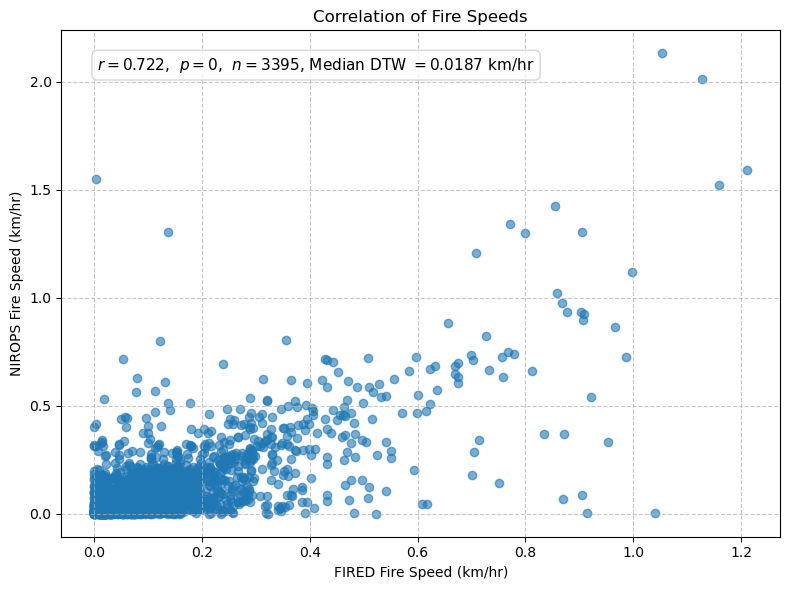

In [162]:
# After computing speeds on both datasets, add the date back as a merge key
# gdf_nirops_processed and gdf_fired_processed both have NIROPS_perim_date
merge_cols = ["NIROPS_Incident_C", "NIROPS_perim_date"]
df_nirops_speeds = gdf_nirops_processed[merge_cols + ["nirops_fire_speed", "nirops_fire_distance"]].copy()
df_fired_speeds  = gdf_fired_processed[merge_cols + ["fired_fire_speed", "fired_fire_distance"]].copy()

# Inner join: only keep dates where BOTH datasets have a speed measurement
df_merged = df_nirops_speeds.merge(df_fired_speeds, on=merge_cols, how="inner")

# Drop NaN and zero-speed rows (identical geometry timesteps)
df_merged = df_merged.dropna(subset=["nirops_fire_speed", "fired_fire_speed"])

print(f"Matched pairs: {len(df_merged)}")
print(f"Fires represented: {df_merged['NIROPS_Incident_C'].nunique()}")

# ── Remove outliers via IQR fence on both speed columns ──────────────────────
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

n_lo, n_hi = iqr_bounds(df_merged["nirops_fire_speed"])
f_lo, f_hi = iqr_bounds(df_merged["fired_fire_speed"])

mask = (
    df_merged["nirops_fire_speed"].between(n_lo, n_hi) &
    df_merged["fired_fire_speed"].between(f_lo, f_hi)
)
n_removed = (~mask).sum()
df_merged = df_merged#[mask].reset_index(drop=True)

print(f"Outliers removed : {n_removed} rows ({n_removed / (len(df_merged) + n_removed):.1%})")
print(f"Matched pairs    : {len(df_merged)}")
print(f"Fires represented: {df_merged['NIROPS_Incident_C'].nunique()}")


# ── Pearson r (existing) ───────────────────────────────────────────────────────
r_value, p_value = pearsonr(df_merged["fired_fire_speed"], df_merged["nirops_fire_speed"])

# ── Weighted correlation with time-decay kernel (per fire) ────────────────────
# For each fire, every pair of observations (i, j) is weighted by
#   w_ij = exp(-lambda * |date_i - date_j| in days)
# so pairs close in time contribute more to the correlation.
# The weighted correlation is then averaged across fires (weighted by n_pairs).
#
# Lambda controls decay rate:
#   λ=0.5 → weight drops to ~0.14 at 4 days apart  (tight)
#   λ=0.2 → weight drops to ~0.45 at 4 days apart  (moderate)
#   λ=0.1 → weight drops to ~0.67 at 4 days apart  (gentle)

DECAY_LAMBDA = 0.1

def weighted_corr_time_decay(dates, x, y, lam):
    """
    Weighted Pearson correlation where each observation pair (i, j) is
    weighted by exp(-lam * |date_i - date_j| in days).
    Returns the scalar weighted correlation for one fire's time series.
    """
    dates = pd.to_datetime(dates).values
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n = len(x)
    if n < 2:
        return np.nan

    # Pairwise day differences
    day_diff = np.abs(
        (dates[:, None] - dates[None, :]).astype("timedelta64[D]").astype(float)
    )
    W = np.exp(-lam * day_diff)           # n×n weight matrix

    # Weighted means
    w_sum = W.sum(axis=1)                 # per-row sum of weights
    mx = (W * x[None, :]).sum(axis=1) / w_sum   # each obs weighted by its row
    my = (W * y[None, :]).sum(axis=1) / w_sum

    # Use the diagonal weight vector (self-weight = 1) for the standard formula
    w_diag = np.diag(W)                   # weight of each obs with itself
    wx = w_diag / w_diag.sum()

    x_c = x - (wx * x).sum() / wx.sum() * wx.sum()   # simplifies to demeaning
    # Standard weighted Pearson using row-sum weights
    w_total = W.sum()
    xc = x - (W * x[None, :]).sum() / w_total
    yc = y - (W * y[None, :]).sum() / w_total

    cov_w  = (W * np.outer(xc, yc)).sum() / w_total
    var_wx = (W * np.outer(xc, xc)).sum() / w_total
    var_wy = (W * np.outer(yc, yc)).sum() / w_total

    denom = np.sqrt(var_wx * var_wy)
    return cov_w / denom if denom > 0 else np.nan

df_merged_sorted = df_merged.sort_values(["NIROPS_Incident_C", "NIROPS_perim_date"])

wcorr_results = []
for fire_id, grp in df_merged_sorted.groupby("NIROPS_Incident_C"):
    if len(grp) < 2:
        continue
    wc = weighted_corr_time_decay(
        grp["NIROPS_perim_date"],
        grp["fired_fire_speed"].values,
        grp["nirops_fire_speed"].values,
        lam=DECAY_LAMBDA,
    )
    wcorr_results.append({"NIROPS_Incident_C": fire_id, "weighted_corr": wc, "n": len(grp)})

df_wcorr = pd.DataFrame(wcorr_results).dropna(subset=["weighted_corr"])

# Aggregate: weighted mean across fires (weight by number of timesteps)
wc_global = np.average(df_wcorr["weighted_corr"], weights=df_wcorr["n"])
print(f"\nWeighted correlation (λ={DECAY_LAMBDA}) across {len(df_wcorr)} fires:")
print(f"  Weighted-mean r : {wc_global:.3f}")
print(f"  Median r        : {df_wcorr['weighted_corr'].median():.3f}")


# ── DTW with a ±2-day warping window (per fire) ───────────────────────────────
# dtaidistance works on 1-D numpy arrays; window is in number of timesteps.
# We compute DTW per fire (each fire has its own time series) then aggregate.
DTW_WINDOW = 2   # ±2 timesteps (~days, given daily perimeters)

dtw_results = []   # one row per fire: {fire, dtw_dist, n_timesteps}

df_merged_sorted = df_merged.sort_values(["NIROPS_Incident_C", "NIROPS_perim_date"])
for fire_id, grp in df_merged_sorted.groupby("NIROPS_Incident_C"):
    s_nirops = grp["nirops_fire_speed"].values.astype(np.float64)
    s_fired  = grp["fired_fire_speed"].values.astype(np.float64)
    if len(s_nirops) < 2:
            continue
    dist = dtaidtw.distance_fast(s_nirops, s_fired, window=DTW_WINDOW)
    dtw_results.append({
            "NIROPS_Incident_C": fire_id,
            "dtw_distance":      dist,
            "n_timesteps":       len(s_nirops),
        })

df_dtw = pd.DataFrame(dtw_results)
# Length-normalise so longer fires don't dominate
df_dtw["dtw_distance_norm"] = df_dtw["dtw_distance"] / df_dtw["n_timesteps"]

median_dtw      = df_dtw["dtw_distance"].median()
median_dtw_norm = df_dtw["dtw_distance_norm"].median()
print(f"\nDTW (window={DTW_WINDOW} steps) across {len(df_dtw)} fires:")
print(f"  Median DTW distance          : {median_dtw:.4f} km/hr")
print(f"  Median DTW distance (per-step): {median_dtw_norm:.4f} km/hr")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nPearson r  : {r_value:.3f}  (p = {p_value:.3g},  n = {len(df_merged)})")
print(f"Weighted r (λ={DECAY_LAMBDA}) : {wc_global:.3f}")

# ── Scatterplot ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(df_merged["fired_fire_speed"], df_merged["nirops_fire_speed"], alpha=0.6)
plt.xlabel("FIRED Fire Speed (km/hr)")
plt.ylabel("NIROPS Fire Speed (km/hr)")
plt.title("Correlation of Fire Speeds")

stats_text = (
    f"$r = {r_value:.3f}$,  $p = {p_value:.3g}$,  $n = {len(df_merged)}$, Median DTW $= {median_dtw_norm:.4f}$ km/hr"
)
     

plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.8, ec="#ccc"))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Fires with all three metrics: 285


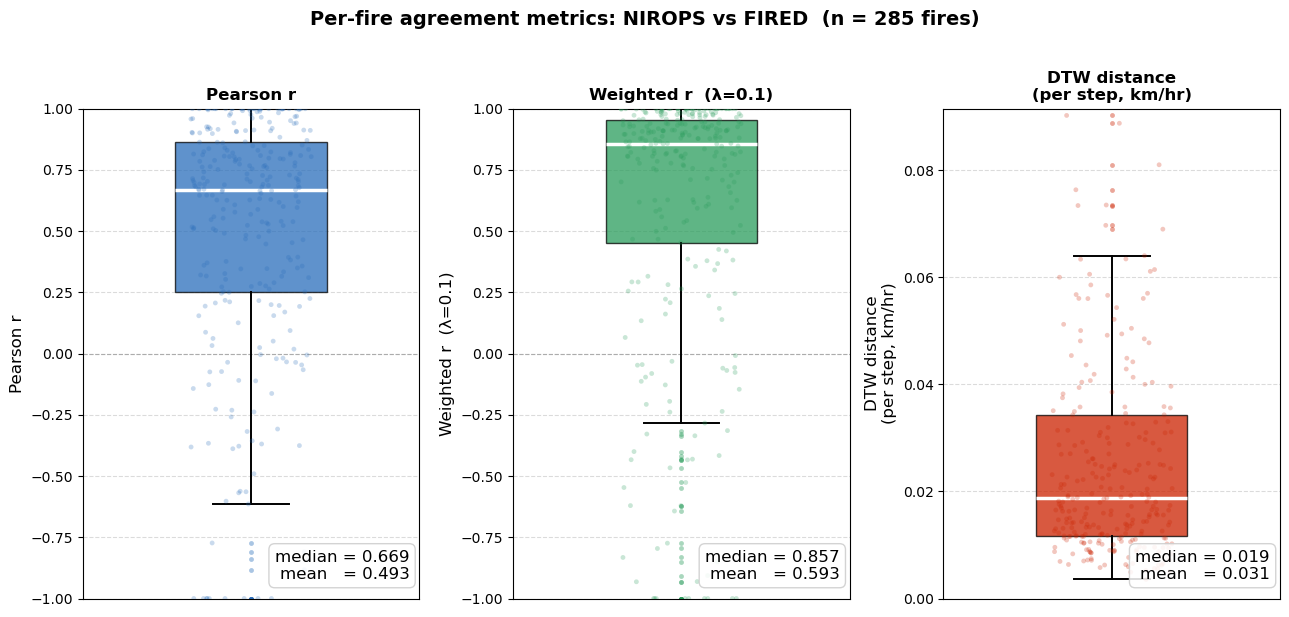

In [158]:
# ── Per-fire Pearson r ────────────────────────────────────────────────────────
pearson_results = []
for fire_id, grp in df_merged_sorted.groupby("NIROPS_Incident_C"):
    grp = grp.dropna(subset=["nirops_fire_speed", "fired_fire_speed"])
    grp = grp[(grp["nirops_fire_speed"] > 0) & (grp["fired_fire_speed"] > 0)]
    if len(grp) < 2:
        continue
    r, p = pearsonr(grp["fired_fire_speed"], grp["nirops_fire_speed"])
    pearson_results.append({"NIROPS_Incident_C": fire_id, "pearson_r": r, "n": len(grp)})

df_pearson = pd.DataFrame(pearson_results).dropna(subset=["pearson_r"])

# ── Merge all per-fire stats into one dataframe ───────────────────────────────
df_perfire = (
    df_pearson
    .merge(df_wcorr.rename(columns={"weighted_corr": "weighted_r"}),
           on=["NIROPS_Incident_C", "n"], how="inner")
    .merge(df_dtw[["NIROPS_Incident_C", "dtw_distance_norm"]],
           on="NIROPS_Incident_C", how="inner")
)
print(f"Fires with all three metrics: {len(df_perfire)}")

# ── Three boxplots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 6))

dtw_95 = df_perfire["dtw_distance_norm"].quantile(0.95)

metrics = [
    ("pearson_r",        "Pearson r",                      "#2A6EBB", (-1, 1)),
    ("weighted_r",       f"Weighted r  (λ={DECAY_LAMBDA})", "#2A9D5C", (-1, 1)),
    ("dtw_distance_norm","DTW distance\n(per step, km/hr)", "#CC2200", (0, dtw_95)),
]

for ax, (col, label, color, ylim) in zip(axes, metrics):
    data = df_perfire[col].dropna()

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker="o", markersize=3.5, alpha=0.4,
                        markerfacecolor=color, markeredgecolor="none"),
    )
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.75)

    # Jittered points overlaid
    jitter = np.random.uniform(-0.18, 0.18, size=len(data))
    ax.scatter(1 + jitter, data, color=color, alpha=0.25, s=12, zorder=3,
               edgecolors="none")

    median_val = data.median()
    mean_val   = data.mean()
    if col != "dtw_distance_norm":
        ax.axhline(0, color="#aaa", lw=0.8, ls="--", zorder=0)

    stats_str = (
        f"median = {median_val:.3f}\n"
        f"mean   = {mean_val:.3f}"
    )
    ax.text(0.97, 0.10, stats_str, transform=ax.transAxes,
            fontsize=12, ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.85, ec="#ccc"))

    ax.set_xticks([])
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.45)

    if ylim[0] is not None:
        ax.set_ylim(bottom=ylim[0])
    if ylim[1] is not None:
        ax.set_ylim(ylim[0], ylim[1])

fig.suptitle(
    f"Per-fire agreement metrics: NIROPS vs FIRED  (n = {len(df_perfire)} fires)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

In [138]:
df_pearson[(df_pearson['pearson_r'] > 0.9) & (df_pearson['n'] > 3)]

,NIROPS_Incident_C,pearson_r,n
0,AZ-ASF-000613_Horton,0.967672,4
8,AZ-CRD-001644_Ridge,0.965146,4
10,AZ-GID-000387_Mescal,0.942200,6
20,AZ-SCA-001403_BlueRiver,0.911690,8
22,AZ-SCA-002036_BlueRiver2,0.996184,4
44,CA-ENF-024030_Caldor,0.913063,28
56,CA-KNP-000122_KNPComplex,0.915776,25
62,CA-LPF-002428_Dolan,0.920131,20
66,CA-MNF-000753_AugustComplex,0.926317,45
70,CA-ORC-136890_Bond,0.945208,5


In [142]:
def idxmax_date(group, speed_col, date_col="NIROPS_perim_date"):
    """Return the date corresponding to the row with the highest speed.
    Returns NaT if the group has no valid (non-NaN) speed values."""
    valid = group[speed_col].dropna()
    if valid.empty:
        return pd.NaT
    idx = valid.idxmax()
    return group.loc[idx, date_col]
 
nirops_max = (
    gdf_nirops_processed
    .groupby("NIROPS_Incident_C")
    .apply(lambda g: pd.Series({
        "nirops_max_speed": g["nirops_fire_speed"].max(),
        "nirops_max_speed_date": idxmax_date(g, "nirops_fire_speed"),
    }))
    .reset_index()
)
 
fired_max = (
    gdf_fired_processed
    .groupby("NIROPS_Incident_C")
    .apply(lambda g: pd.Series({
        "fired_max_speed": g["fired_fire_speed"].max(),
        "fired_max_speed_date": idxmax_date(g, "fired_fire_speed"),
    }))
    .reset_index()
)
 
gdf_max_speed = nirops_max.merge(fired_max, on="NIROPS_Incident_C", how="inner")
 
# Ensure date columns are datetime
gdf_max_speed["nirops_max_speed_date"] = pd.to_datetime(gdf_max_speed["nirops_max_speed_date"])
gdf_max_speed["fired_max_speed_date"]  = pd.to_datetime(gdf_max_speed["fired_max_speed_date"])
 
# Date difference: FIRED minus NIROPS (positive = FIRED peak came later)
gdf_max_speed["max_speed_date_diff_days"] = (
    gdf_max_speed["fired_max_speed_date"] - gdf_max_speed["nirops_max_speed_date"]
).dt.days
 
# Drop rows where either max speed is NaN or zero (no valid speed recorded)
gdf_max_speed = gdf_max_speed.dropna(subset=["nirops_max_speed", "fired_max_speed",
                                              "nirops_max_speed_date", "fired_max_speed_date"])
gdf_max_speed = gdf_max_speed[
    (gdf_max_speed["nirops_max_speed"] > 0) &
    (gdf_max_speed["fired_max_speed"]  > 0)
].reset_index(drop=True)
 
print(f"Events in gdf_max_speed: {len(gdf_max_speed)}")
print(gdf_max_speed[["NIROPS_Incident_C", "nirops_max_speed", "nirops_max_speed_date",
                      "fired_max_speed", "fired_max_speed_date",
                      "max_speed_date_diff_days"]].head(10))
 
 

Events in gdf_max_speed: 336
        NIROPS_Incident_C  nirops_max_speed nirops_max_speed_date  \
0   AZ-A4S-000950_Central          0.093879            2020-06-22   
1     AZ-A5S-230970_Pilot          0.047910            2023-07-11   
2    AZ-ASF-000613_Horton          0.280129            2021-06-22   
3      AZ-ASF-000624_Bear          0.334513            2021-06-22   
4    AZ-ASF-000662_Wyrick          0.031856            2021-06-25   
5   AZ-ASF-00083_Bringham          0.229998            2020-06-13   
6   AZ-CNF-000413_Bighorn          0.347595            2020-06-19   
7  AZ-CNF-000427_Pinnacle          0.171753            2021-06-17   
8   AZ-CNF-000552_Beehive          0.177024            2023-07-04   
9  AZ-COF-000523_Pipeline          0.131180            2022-06-16   

   fired_max_speed fired_max_speed_date  max_speed_date_diff_days  
0         0.142830           2020-06-22                       0.0  
1         0.077977           2023-07-11                       0.0  
2      

/var/folders/1q/y8d8lsnn4h14mtfn3x9p0k540000gr/T/ipykernel_32863/499704316.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/1q/y8d8lsnn4h14mtfn3x9p0k540000gr/T/ipykernel_32863/499704316.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


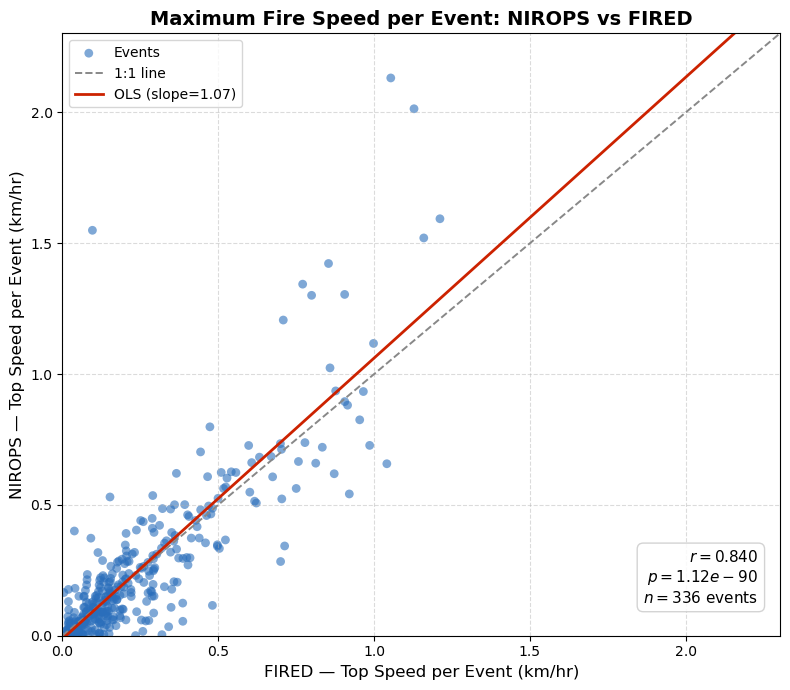

In [143]:
# ── Scatterplot: top speed per event — NIROPS vs FIRED ───────────────────────
r, p = pearsonr(gdf_max_speed["fired_max_speed"], gdf_max_speed["nirops_max_speed"])

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    gdf_max_speed["fired_max_speed"],
    gdf_max_speed["nirops_max_speed"],
    alpha=0.6, s=40,
    color="#2A6EBB", edgecolors="none",
    label="Events"
)

# 1-to-1 reference line
vmax = max(
    gdf_max_speed["fired_max_speed"].max(),
    gdf_max_speed["nirops_max_speed"].max()
) * 1.08
ax.plot([0, vmax], [0, vmax], color="#888", lw=1.4, ls="--", label="1:1 line")

# OLS trend line
m, b = np.polyfit(gdf_max_speed["fired_max_speed"], gdf_max_speed["nirops_max_speed"], 1)
xfit = np.linspace(0, vmax, 200)
ax.plot(xfit, m * xfit + b, color="#CC2200", lw=2, label=f"OLS (slope={m:.2f})")

ax.set_xlim(0, vmax)
ax.set_ylim(0, vmax)
ax.set_xlabel("FIRED — Top Speed per Event (km/hr)", fontsize=12)
ax.set_ylabel("NIROPS — Top Speed per Event (km/hr)", fontsize=12)
ax.set_title("Maximum Fire Speed per Event: NIROPS vs FIRED", fontsize=14, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.45)
ax.legend(fontsize=10, loc="upper left")

stats_str = (
    f"$r = {r:.3f}$\n"
    f"$p = {p:.3g}$\n"
    f"$n = {len(gdf_max_speed)}$ events"
)
ax.text(
    0.97, 0.05, stats_str,
    transform=ax.transAxes, fontsize=11,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85, ec="#ccc")
)

plt.tight_layout()
plt.show()


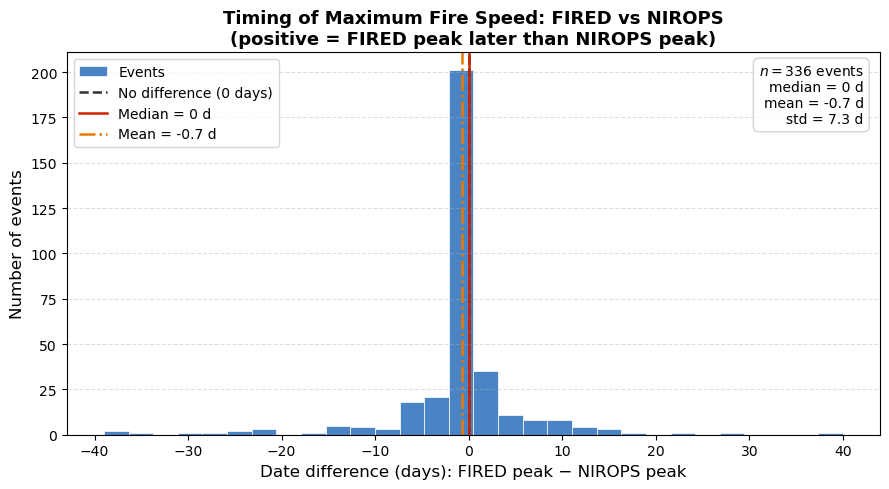

In [55]:
# ── Histogram: date difference between FIRED and NIROPS peak speed day ────────
diff = gdf_max_speed["max_speed_date_diff_days"].dropna()

median_diff = diff.median()
mean_diff   = diff.mean()

fig2, ax2 = plt.subplots(figsize=(9, 5))

ax2.hist(
    diff,
    bins=30,
    color="#2A6EBB", edgecolor="white", linewidth=0.6,
    alpha=0.85,
    label="Events"
)

ax2.axvline(0,           color="#333",    lw=1.8, ls="--", label="No difference (0 days)")
ax2.axvline(median_diff, color="#CC2200", lw=1.8, ls="-",  label=f"Median = {median_diff:.0f} d")
ax2.axvline(mean_diff,   color="#E87800", lw=1.8, ls="-.", label=f"Mean = {mean_diff:.1f} d")

ax2.set_xlabel("Date difference (days): FIRED peak − NIROPS peak", fontsize=12)
ax2.set_ylabel("Number of events", fontsize=12)
ax2.set_title(
    "Timing of Maximum Fire Speed: FIRED vs NIROPS\n"
    "(positive = FIRED peak later than NIROPS peak)",
    fontsize=13, fontweight="bold"
)
ax2.grid(True, linestyle="--", alpha=0.4, axis="y")
ax2.legend(fontsize=10)

stats_str2 = (
    f"$n = {len(diff)}$ events\n"
    f"median = {median_diff:.0f} d\n"
    f"mean = {mean_diff:.1f} d\n"
    f"std = {diff.std():.1f} d"
)
ax2.text(
    0.98, 0.97, stats_str2,
    transform=ax2.transAxes, fontsize=10,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85, ec="#ccc")
)

plt.tight_layout()
plt.show()

In [84]:
print(sum(gdf_max_speed["max_speed_date_diff_days"] == 0))
gdf_max_speed[gdf_max_speed["max_speed_date_diff_days"] < -5]

160


,NIROPS_Incident_C,nirops_max_speed,nirops_max_speed_date,fired_max_speed,fired_max_speed_date,max_speed_date_diff_days
55,CA-KNF-006385_RiverComplex_Cronan,0.090941,2021-08-19,0.126891,2021-08-08,-11.0
56,CA-KNF-006385_RiverComplex_RiverComplex,0.437087,2021-09-20,0.250447,2021-09-04,-16.0
57,CA-KNF-006454_Antelope,0.568711,2021-09-12,0.248225,2021-08-18,-25.0
87,CA-PNF-001299_Sheep,0.435836,2020-08-28,0.221561,2020-08-22,-6.0
105,CA-SQF-002541_Castle,0.342711,2020-10-19,0.321118,2020-09-13,-36.0
107,CA-SRF-000651_McCash,0.196297,2021-09-09,0.147032,2021-08-30,-10.0
111,CA-SRF-000986_Pearch,0.098620,2023-09-23,0.114082,2023-09-10,-13.0
112,CA-SRF-000986_SRFLightningWest,0.418364,2023-09-20,0.105372,2023-09-13,-7.0
119,CO-ARF-000636_CameronPeak,0.825251,2020-10-17,0.953975,2020-09-08,-39.0
123,CO-GRD-000307_PineGulch,0.487239,2020-08-20,0.481688,2020-08-08,-12.0


In [131]:
random.seed(22)
all_keys_nirops = set(gdf_nirops['NIROPS_Incident_C'].unique())
all_keys_fired  = set(gdf_fired['NIROPS_Incident_C'].unique())
shared_keys = list(all_keys_nirops & all_keys_fired)

# ── Optional: pin a specific fire instead of searching randomly ───────────────
# Set to a NIROPS_Incident_C string to force that fire, or None to search randomly.
#FORCE_KEY = None                             # random search 
FORCE_KEY = "CA-PNF-001308_PNFNorthComplex"  # specific fire
# ─────────────────────────────────────────────────────────────────────────────

if FORCE_KEY is not None:
    if FORCE_KEY not in shared_keys:
        raise ValueError(f"FORCE_KEY '{FORCE_KEY}' not found in shared NIROPS/FIRED keys.")
    search_keys = [FORCE_KEY]
    print(f"Using specified fire: {FORCE_KEY}")
else:
    random.shuffle(shared_keys)
    search_keys = shared_keys

# Pick a fire that has ≥6 timesteps in both datasets and ≥2 coincident dates
chosen_key = None
nirops_proc = fired_proc = None

for key in search_keys:
    grp_n = gdf_nirops[gdf_nirops['NIROPS_Incident_C'] == key].drop_duplicates('NIROPS_UTC').copy()
    grp_f = gdf_fired [gdf_fired ['NIROPS_Incident_C'] == key].drop_duplicates('NIROPS_UTC').copy()
    if len(grp_n) < 6 or len(grp_f) < 6:
        continue

    dn = build_cumulative_perims(grp_n, id_col='NIROPS_Incident_C', date_col='NIROPS_perim_date')
    df = build_cumulative_perims(grp_f, id_col='NIROPS_Incident_C', date_col='NIROPS_perim_date')

    ox_n, oy_n, dx_n, dy_n, dist_n, spd_n = computefirespeed(dn, id_col='NIROPS_Incident_C')
    ox_f, oy_f, dx_f, dy_f, dist_f, spd_f = computefirespeed(df, id_col='NIROPS_Incident_C')

    dn['nirops_max_vec_origin_x'] = ox_n; dn['nirops_max_vec_origin_y'] = oy_n
    dn['nirops_max_vec_dest_x']   = dx_n; dn['nirops_max_vec_dest_y']   = dy_n
    dn['nirops_fire_speed'] = spd_n

    df['fired_max_vec_origin_x'] = ox_f; df['fired_max_vec_origin_y'] = oy_f
    df['fired_max_vec_dest_x']   = dx_f; df['fired_max_vec_dest_y']   = dy_f
    df['fired_fire_speed'] = spd_f

    # Find coincident dates
    dates_n = set(dn['NIROPS_perim_date'].dt.normalize())
    dates_f = set(df['NIROPS_perim_date'].dt.normalize())
    coincident = sorted(dates_n & dates_f)
    if len(coincident) < 2:
        continue

    chosen_key = key
    nirops_proc = dn
    fired_proc  = df
    print(f"Selected fire: {chosen_key}  |  NIROPS timesteps: {len(dn)}  |  FIRED timesteps: {len(df)}  |  Coincident: {len(coincident)}")
    break

if chosen_key is None:
    raise RuntimeError("No suitable fire found — try removing the ≥6-timestep filter or check your FORCE_KEY.")

# ── Build unified date list (all NIROPS + all FIRED timesteps) ─────────────────
nirops_proc['NIROPS_perim_date'] = pd.to_datetime(nirops_proc['NIROPS_perim_date'])
fired_proc ['NIROPS_perim_date'] = pd.to_datetime(fired_proc ['NIROPS_perim_date'])

all_dates = sorted(set(nirops_proc['NIROPS_perim_date'].dt.normalize()) |
                   set(fired_proc ['NIROPS_perim_date'].dt.normalize()))

n_ts = len(all_dates)

# ── Correlation for the chosen fire ───────────────────────────────────────────
from scipy.stats import pearsonr

merged_spd = pd.merge(
    nirops_proc[['NIROPS_perim_date', 'nirops_fire_speed']].dropna(),
    fired_proc [['NIROPS_perim_date', 'fired_fire_speed' ]].dropna(),
    on='NIROPS_perim_date', how='inner'
)
merged_spd = merged_spd[(merged_spd['nirops_fire_speed'] > 0) &
                        (merged_spd['fired_fire_speed']  > 0)]

if len(merged_spd) >= 2:
    r_val, p_val = pearsonr(merged_spd['nirops_fire_speed'], merged_spd['fired_fire_speed'])
    corr_str = f"r = {r_val:.3f},  p = {p_val:.3g},  n = {len(merged_spd)}"
else:
    r_val, corr_str = np.nan, "r = N/A (insufficient paired speed observations)"

print(f"\nSpeed correlation for {chosen_key}:  {corr_str}\n")

# ── Build an index of prior-day cum_geom for each dataset ─────────────────────
# For each row at position i, prior_geom is cum_geom at i-1 (same fire, else None).
def add_prior_geom(gdf, id_col='NIROPS_Incident_C', date_col='NIROPS_perim_date'):
    gdf = gdf.sort_values(date_col).reset_index(drop=True).copy()
    prior = [None] * len(gdf)
    for i in range(1, len(gdf)):
        if gdf.iloc[i][id_col] == gdf.iloc[i-1][id_col]:
            prior[i] = gdf.iloc[i-1]['cum_geom']
    gdf['prior_cum_geom'] = prior
    return gdf

nirops_proc = add_prior_geom(nirops_proc)
fired_proc  = add_prior_geom(fired_proc)

Using specified fire: CA-PNF-001308_PNFNorthComplex
Selected fire: CA-PNF-001308_PNFNorthComplex  |  NIROPS timesteps: 47  |  FIRED timesteps: 47  |  Coincident: 46

Speed correlation for CA-PNF-001308_PNFNorthComplex:  r = 0.951,  p = 5e-22,  n = 42



Text(0.5, 1.01, 'Fire: CA-PNF-001308_PNFNorthComplex\nNIROPS & FIRED perimeters with max-speed vectors  |  Speed correlation: r = 0.951,  p = 5e-22,  n = 42')

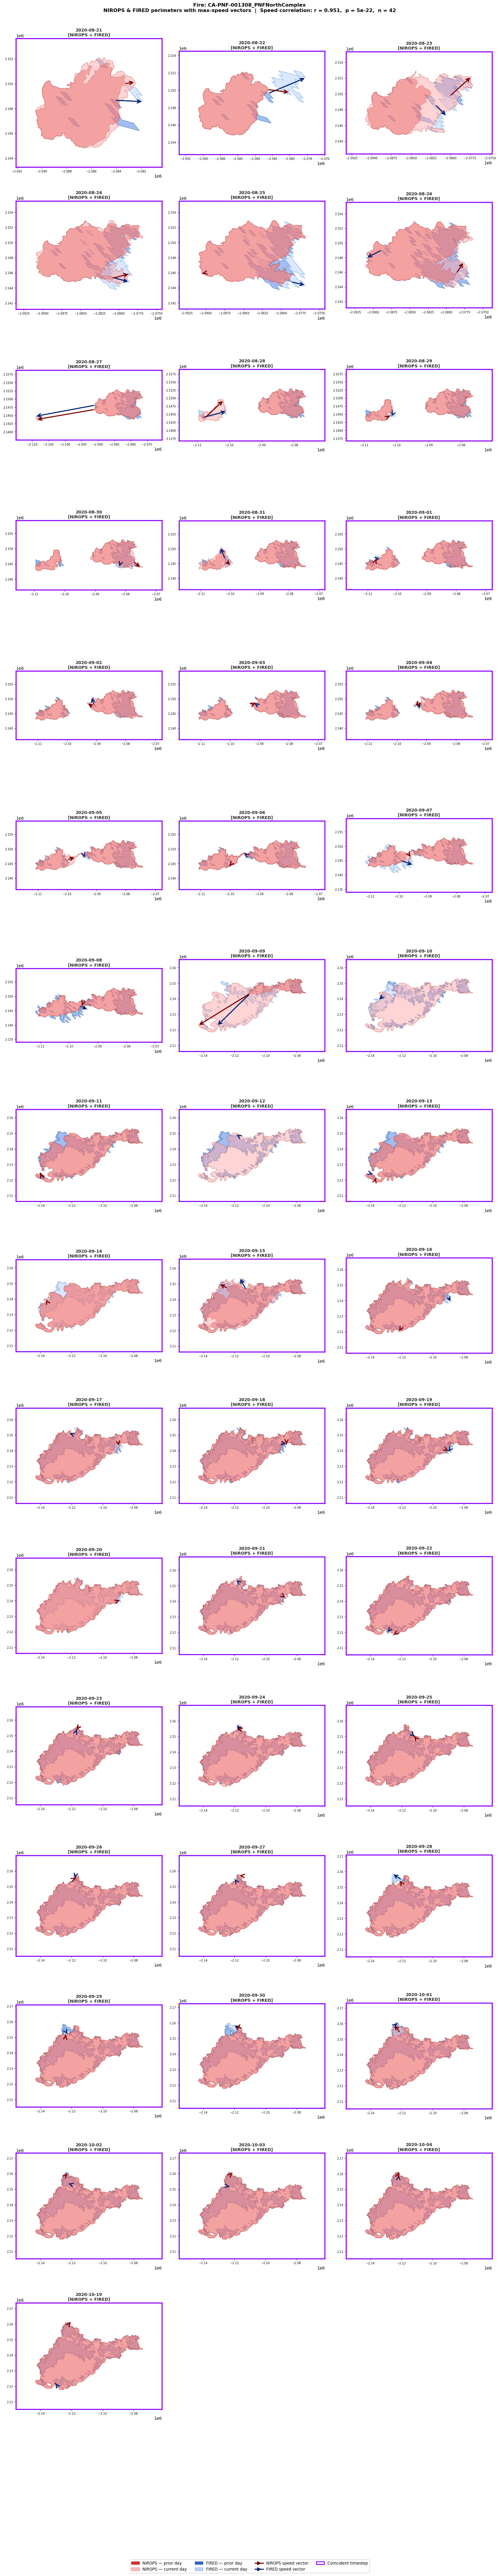

In [132]:
## ── Figure layout ──────────────────────────────────────────────────────────────
ncols = min(3, n_ts)
nrows = (n_ts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()
 
# Colour palette
# NIROPS: light red (prior) → dark red (current)
C_NIROPS_PRIOR_FILL = '#CC0000'
C_NIROPS_PRIOR_EDGE = '#7A0000'

C_NIROPS_CURR_FILL  = '#FFAAAA'
C_NIROPS_CURR_EDGE  = '#CC6666'
C_NIROPS_ARROW      = '#7A0000'
 
# FIRED: light blue (prior) → dark blue (current)
C_FIRED_PRIOR_FILL  = '#0044CC'
C_FIRED_PRIOR_EDGE  = '#002277'

C_FIRED_CURR_FILL   = '#AACCFF'
C_FIRED_CURR_EDGE   = '#6699CC'

C_FIRED_ARROW       = '#002277'
 
 
def plot_geom(ax, geom, fc, ec, alpha=0.45, lw=1.4, zorder=2):
    gdf_tmp = gpd.GeoDataFrame(geometry=[geom], crs=nirops_proc.crs)
    gdf_tmp.plot(ax=ax, facecolor=fc, edgecolor=ec, linewidth=lw, alpha=alpha, zorder=zorder)
 
 
def draw_arrow(ax, ox, oy, dx, dy, color, zorder=5):
    if any(v is None or (isinstance(v, float) and np.isnan(v)) for v in [ox, oy, dx, dy]):
        return
    ax.annotate('', xy=(dx, dy), xytext=(ox, oy),
                 arrowprops=dict(arrowstyle='->', color=color, lw=2.5,
                                 mutation_scale=20),
                 zorder=zorder)
 
 
for idx, date in enumerate(all_dates):
    ax = axes[idx]
 
    row_n = nirops_proc[nirops_proc['NIROPS_perim_date'].dt.normalize() == date]
    row_f = fired_proc [fired_proc ['NIROPS_perim_date'].dt.normalize() == date]
 
    has_n = len(row_n) > 0
    has_f = len(row_f) > 0
 
    geoms_for_extent = []
 
    # ── FIRED layers (drawn first, underneath NIROPS) ──────────────────────────
    if has_f:
        r = row_f.iloc[-1]
        curr_f  = r['cum_geom']
        prior_f = r['prior_cum_geom']
 
        # prior (light blue) — only when it differs from current
        if prior_f is not None and not prior_f.equals(curr_f):
            plot_geom(ax, prior_f, C_FIRED_PRIOR_FILL, C_FIRED_PRIOR_EDGE,
                      alpha=0.40, lw=1.2, zorder=2)
            geoms_for_extent.append(prior_f)
 
        # current (dark blue)
        plot_geom(ax, curr_f, C_FIRED_CURR_FILL, C_FIRED_CURR_EDGE,
                  alpha=0.45, lw=1.6, zorder=3)
        geoms_for_extent.append(curr_f)
 
        draw_arrow(ax,
                   r['fired_max_vec_origin_x'], r['fired_max_vec_origin_y'],
                   r['fired_max_vec_dest_x'],   r['fired_max_vec_dest_y'],
                   C_FIRED_ARROW, zorder=6)
 
    # ── NIROPS layers (on top of FIRED) ───────────────────────────────────────
    if has_n:
        r = row_n.iloc[-1]
        curr_n  = r['cum_geom']
        prior_n = r['prior_cum_geom']
 
        # prior (light red)
        if prior_n is not None and not prior_n.equals(curr_n):
            plot_geom(ax, prior_n, C_NIROPS_PRIOR_FILL, C_NIROPS_PRIOR_EDGE,
                      alpha=0.40, lw=1.2, zorder=4)
            geoms_for_extent.append(prior_n)
 
        # current (dark red)
        plot_geom(ax, curr_n, C_NIROPS_CURR_FILL, C_NIROPS_CURR_EDGE,
                  alpha=0.50, lw=1.6, zorder=5)
        geoms_for_extent.append(curr_n)
 
        draw_arrow(ax,
                   r['nirops_max_vec_origin_x'], r['nirops_max_vec_origin_y'],
                   r['nirops_max_vec_dest_x'],   r['nirops_max_vec_dest_y'],
                   C_NIROPS_ARROW, zorder=7)
 
    # ── Extent / padding ──────────────────────────────────────────────────────
    if geoms_for_extent:
        from shapely.ops import unary_union as uu
        combined = uu(geoms_for_extent)
        xmin, ymin, xmax, ymax = combined.bounds
        pad = max((xmax - xmin), (ymax - ymin)) * 0.18
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(ymin - pad, ymax + pad)
 
    is_coincident = has_n and has_f
    border_color = '#8B00FF' if is_coincident else 'grey'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5 if is_coincident else 1)
 
    date_str = date.strftime('%Y-%m-%d')
    tags = []
    if has_n: tags.append('NIROPS')
    if has_f: tags.append('FIRED')
    tag_str = ' + '.join(tags) if tags else 'none'
 
    ax.set_title(f"{date_str}\n[{tag_str}]", fontsize=10, fontweight='bold',
                 color='#2d2d2d', pad=5)
    ax.tick_params(labelsize=7)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
 
# Hide unused axes
for j in range(n_ts, len(axes)):
    axes[j].set_visible(False)
 
# ── Legend ─────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
 
legend_handles = [
    mpatches.Patch(facecolor=C_NIROPS_PRIOR_FILL, edgecolor=C_NIROPS_PRIOR_EDGE, alpha=0.8,
                   label='NIROPS — prior day'),
    mpatches.Patch(facecolor=C_NIROPS_CURR_FILL,  edgecolor=C_NIROPS_CURR_EDGE,  alpha=0.8,
                   label='NIROPS — current day'),
    mpatches.Patch(facecolor=C_FIRED_PRIOR_FILL,  edgecolor=C_FIRED_PRIOR_EDGE,  alpha=0.8,
                   label='FIRED — prior day'),
    mpatches.Patch(facecolor=C_FIRED_CURR_FILL,   edgecolor=C_FIRED_CURR_EDGE,   alpha=0.8,
                   label='FIRED — current day'),
    Line2D([0], [0], color=C_NIROPS_ARROW, lw=2.5, marker='>', markersize=8,
           label='NIROPS speed vector'),
    Line2D([0], [0], color=C_FIRED_ARROW,  lw=2.5, marker='>', markersize=8,
           label='FIRED speed vector'),
    mpatches.Patch(facecolor='none', edgecolor='#8B00FF', linewidth=2,
                   label='Coincident timestep'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, fontsize=9.5, frameon=True, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.06))
 
# ── Super-title (includes correlation) ────────────────────────────────────────
fire_name = str(chosen_key)
fig.suptitle(
    f"Fire: {fire_name}\n"
    f"NIROPS & FIRED perimeters with max-speed vectors  |  Speed correlation: {corr_str}",
    fontsize=12, fontweight='bold', y=1.01
)
 
#out_path = '/mnt/user-data/outputs/fire_timesteps.png'
#fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
#print(f"Saved → {out_path}")
#plt.close(fig)

In [111]:
def computefirespeed(fire_gdf, id_col="id"):
    if fire_gdf.crs is None or fire_gdf.crs.is_geographic:
        raise ValueError(
            f"computefirespeed requires projected CRS in meters, got {fire_gdf.crs}"
        )
    transformer = pyproj.Transformer.from_crs(fire_gdf.crs, "EPSG:4326", always_xy=True)
    geod = pyproj.Geod(ellps="WGS84")
    fire_gdf = fire_gdf.reset_index(drop=True).copy()
    n_rows = fire_gdf.shape[0]
    orig_x = [np.nan] * n_rows
    orig_y = [np.nan] * n_rows
    dest_x = [np.nan] * n_rows
    dest_y = [np.nan] * n_rows
    result_max_dist = [np.nan] * n_rows
    result_speed = [np.nan] * n_rows

    has_ids = id_col in fire_gdf.columns

    for i in range(1, fire_gdf.shape[0]):
        if has_ids and fire_gdf.iloc[i][id_col] != fire_gdf.iloc[i - 1][id_col]:
            continue

        prev_geom = fire_gdf.iloc[i - 1].cum_geom
        curr_geom = fire_gdf.iloc[i].cum_geom

        if isinstance(prev_geom, Polygon):
            prev_geom = MultiPolygon([prev_geom])
        if isinstance(curr_geom, Polygon):
            curr_geom = MultiPolygon([curr_geom])

        inter_matrix = np.zeros((len(prev_geom.geoms), len(curr_geom.geoms)), dtype=bool)
        prev_buffered = [p.buffer(1e-6) for p in prev_geom.geoms]
        for ii in range(len(prev_geom.geoms)):
            for jj in range(len(curr_geom.geoms)):
                inter_matrix[ii, jj] = prev_buffered[ii].intersects(curr_geom.geoms[jj])

        prev_coords = [
            prev_geom.geoms[ii].simplify(0.05).exterior.coords
            for ii in range(len(prev_geom.geoms))
        ]

        # --- Skip if geometry is identical between timesteps ---
        if prev_geom.equals(curr_geom):
            result_max_dist[i] = 0
            result_speed[i] = 0
            # orig_x/y and dest_x/y remain NaN
            continue

        best_dist = -np.inf
        best_origin = None
        best_dest = None
        best_child = None

        for j, child_poly in enumerate(curr_geom.geoms):
            parent_ids = np.where(inter_matrix[:, j])[0].tolist()
            spot = len(parent_ids) == 0
            if spot:
                dists = [prev_poly.distance(child_poly) for prev_poly in prev_geom.geoms]
                parent_ids = [int(np.argmin(dists))]

            parent_geoms = [prev_geom.geoms[ii] for ii in parent_ids]
            parent_coords = [prev_coords[ii] for ii in parent_ids]

            dist, origin, dest, parent_local_idx = compute_max_vector(
                perim_inner_geoms=parent_geoms,
                perim_outer_geoms=[child_poly],
                inter_matrix=inter_matrix[parent_ids][:, [j]],
                spot_threshold=25000,
            )

            if dist > best_dist:
                best_dist = dist
                best_origin = origin
                best_dest = dest
                best_child = j

        if best_origin is None:
            continue

        orig_x[i] = best_origin[0]
        orig_y[i] = best_origin[1]
        dest_x[i] = best_dest[0]
        dest_y[i] = best_dest[1]

        lons, lats = transformer.transform(
            [best_origin[0], best_dest[0]],
            [best_origin[1], best_dest[1]]
        )
        dist_m = geod.line_length(lons, lats)
        result_max_dist[i] = dist_m / 1000
        result_speed[i] = (dist_m / 1000) / 24

    return (orig_x, orig_y, dest_x, dest_y, result_max_dist, result_speed)

In [8]:
def compute_max_vector(perim_inner_geoms,
                       perim_outer_geoms,
                       inter_matrix,
                       spot_threshold=4000):

    result_dist = []
    result_coord_pair = []
    result_poly_pair = []
    result_parent_idx = []

    points_per_meter = 1 / 200

    for poly_outer_idx, outer_poly in enumerate(perim_outer_geoms):
        outer_poly = outer_poly.buffer(0)
        spot_flag = not np.any(inter_matrix[:, poly_outer_idx])

        if spot_flag:
            distances = [g.distance(outer_poly) for g in perim_inner_geoms]
            nearest_idx = np.argmin(distances)
            if distances[nearest_idx] > spot_threshold:
                continue
            polyids = [nearest_idx]
            
        else:
            polyids = [ii for ii in range(len(perim_inner_geoms))
                       if inter_matrix[ii, poly_outer_idx]]

        if not polyids:
            continue

        poly_best_dist = -np.inf
        poly_best_pair = None
        poly_best_poly = None
        poly_best_parent_idx = None

        # --- Sample child boundary once ---
        n_child_pts = max(1, int(outer_poly.length * points_per_meter))
        child_pts_sample = sample_perimeter(outer_poly, n_child_pts)
        child_coords_arr = np.array([p.coords[0] for p in child_pts_sample])  # (N_child, 2)

        # --- Check if any parent intersects (vs all spots) ---
        any_intersecting = any(
            perim_inner_geoms[ii].intersects(outer_poly) for ii in polyids
        )

        if any_intersecting:
            # -------------------------------------------------------
            # OVERLAPPING CASE: exact nearest-boundary maximin
            # -------------------------------------------------------

            # Build a combined set of densely-sampled parent boundary points
            # and use STRtree for fast nearest-neighbor lookup
            all_parent_pts = []
            all_parent_pt_ids = []
            all_parent_polys_for_check = []
            
            for ii in polyids:
                parent_poly = perim_inner_geoms[ii].buffer(0)
                if parent_poly.is_empty or not parent_poly.intersects(outer_poly):
                    continue
                n_pts = max(1, int(parent_poly.exterior.length * points_per_meter))
                pts = sample_perimeter(parent_poly, n_pts)
                all_parent_pts.extend(pts)
                all_parent_pt_ids.extend([ii] * len(pts))
                all_parent_polys_for_check.extend([parent_poly] * len(pts))
            
            if not all_parent_pts:
                continue
            
            # Build STRtree on parent boundary points
            tree = STRtree(all_parent_pts)

            # Bulk nearest-neighbor query — replaces per-point loop
            nearest_idxs = tree.nearest(child_pts_sample)  # array of indices, one per child pt

            # Pre-compute which child points are inside any parent (need wrong-side check)
            all_parent_union = unary_union([perim_inner_geoms[ii].buffer(0) for ii in polyids])
            child_inside_mask = np.array([all_parent_union.contains(pt) for pt in child_pts_sample])
            child_outside_mask = ~child_inside_mask  # reuse for fallback

            exact_D_min = np.zeros(len(child_pts_sample))
            exact_nearest_parent_pts = []
            exact_nearest_parent_ids = []

            for ci, (pt_c, nearest_idx) in enumerate(zip(child_pts_sample, nearest_idxs)):
                near_pt = all_parent_pts[nearest_idx]
                parent_poly_b = all_parent_polys_for_check[nearest_idx]
                best_id = all_parent_pt_ids[nearest_idx]

                # Wrong-side check only for child points inside a parent
                if child_inside_mask[ci]:
                    test_line = LineString([near_pt.coords[0], pt_c.coords[0]])
                    if test_line.length > 0:
                        interior_overlap = test_line.intersection(parent_poly_b)
                        interior_fraction = (interior_overlap.length / test_line.length
                                            if not interior_overlap.is_empty else 0)
                        if interior_fraction > 0.1:
                            boundary = parent_poly_b.exterior
                            hits = test_line.intersection(boundary)
                            if not hits.is_empty:
                                near_pt = (min(hits.geoms, key=lambda p: p.distance(pt_c))
                                          if hasattr(hits, 'geoms') else hits)

                exact_D_min[ci] = pt_c.distance(near_pt)
                exact_nearest_parent_pts.append(near_pt)
                exact_nearest_parent_ids.append(best_id)

            # maximin: child point whose nearest parent boundary point is farthest
            best_child_idx = np.argmax(exact_D_min)
            pt_child = np.array(child_pts_sample[best_child_idx].coords[0])
            pt_parent = np.array(exact_nearest_parent_pts[best_child_idx].coords[0])
            chosen_parent_id = exact_nearest_parent_ids[best_child_idx]
            max_dist = exact_D_min[best_child_idx]

            # --- Validate: 75% of vector must be inside child ---
            test_line = LineString([tuple(pt_parent), tuple(pt_child)])

            if test_line.length == 0:
                continue

            child_overlap = test_line.intersection(outer_poly)
            child_length = child_overlap.length if not child_overlap.is_empty else 0
            child_fraction = child_length / test_line.length

            if child_fraction >= 0.75:
                poly_best_dist = max_dist
                poly_best_pair = (pt_parent, pt_child)
                poly_best_poly = (perim_inner_geoms[chosen_parent_id].buffer(0), outer_poly)
                poly_best_parent_idx = chosen_parent_id

            else:
                # --- Fallback: try each child point in descending order of D_min,
                #     find first one whose vector passes the 75% overlap check ---

                sorted_child_rows = np.argsort(exact_D_min)[::-1]  # descending by distance
                outside_rows = [ci for ci in sorted_child_rows if child_outside_mask[ci]]
                rows_to_try = outside_rows if outside_rows else sorted_child_rows  # fallback to all if none outside

                found = False
                for ci in rows_to_try:  
                    candidate_pt_child = np.array(child_pts_sample[ci].coords[0])
                    candidate_pt_parent = np.array(exact_nearest_parent_pts[ci].coords[0])
                    candidate_line = LineString([tuple(candidate_pt_parent), tuple(candidate_pt_child)])
                    if candidate_line.length == 0:
                        continue

                    overlap = candidate_line.intersection(outer_poly)
                    overlap_length = overlap.length if not overlap.is_empty else 0
                    if overlap_length / candidate_line.length >= 0.75:
                        pt_parent = candidate_pt_parent
                        pt_child = candidate_pt_child
                        chosen_parent_id = exact_nearest_parent_ids[ci]
                        max_dist = exact_D_min[ci]
                        found = True
                        break

                if not found:
                    # Last resort: use best maximin result regardless of overlap
                    pt_child = np.array(child_pts_sample[best_child_idx].coords[0])
                    pt_parent = np.array(exact_nearest_parent_pts[best_child_idx].coords[0])
                    chosen_parent_id = exact_nearest_parent_ids[best_child_idx]
                    max_dist = exact_D_min[best_child_idx]

                poly_best_dist = max_dist
                poly_best_pair = (pt_parent, pt_child)
                poly_best_poly = (perim_inner_geoms[chosen_parent_id].buffer(0), outer_poly)
                poly_best_parent_idx = chosen_parent_id

        else:
            # -------------------------------------------------------
            # DISCONNECTED / SPOT FIRE CASE
            # -------------------------------------------------------
            for ii in polyids:
                parent_poly = perim_inner_geoms[ii].buffer(0)
                if parent_poly.is_empty:
                    continue

                pt_parent_sh, pt_child_sh = nearest_points(parent_poly, outer_poly)
                parent_anchor = Point(pt_parent_sh.x, pt_parent_sh.y)
                dists = [pt.distance(parent_anchor) for pt in child_pts_sample]
                best_idx = np.argmax(dists)
                pt_parent = np.array([parent_anchor.x, parent_anchor.y])
                pt_child = np.array(child_pts_sample[best_idx].coords[0])
                max_dist = dists[best_idx]

                if max_dist > poly_best_dist:
                    poly_best_dist = max_dist
                    poly_best_pair = (pt_parent, pt_child)
                    poly_best_poly = (parent_poly, outer_poly)
                    poly_best_parent_idx = ii

        if poly_best_pair is not None:
            result_dist.append(poly_best_dist)
            result_coord_pair.append(poly_best_pair)
            result_poly_pair.append(poly_best_poly)
            result_parent_idx.append(poly_best_parent_idx)

    if result_dist:
        max_loc = np.argmax(result_dist)
        return (
            result_dist[max_loc],
            result_coord_pair[max_loc][0],
            result_coord_pair[max_loc][1],
            result_parent_idx[max_loc]
        )
    else:
        return np.nan, None, None, None

In [6]:
def sample_perimeter(poly, n_points):
    length = poly.length
    if n_points <= 0:
        return []

    distances = np.linspace(0, length, n_points, endpoint=False)
    sampled_pts = [poly.exterior.interpolate(d) for d in distances]

    # Return as Shapely Points, not NumPy arrays
    return [Point(p.x, p.y) for p in sampled_pts]

In [7]:
def build_cumulative_perims(gdf, id_col="id", date_col="date"):
    gdf = gdf.sort_values([id_col, date_col]).copy()
    gdf[date_col] = pd.to_datetime(gdf[date_col])

    cumulative_list = []

    for fire_id, sub_gdf in gdf.groupby(id_col):
        union_so_far = None
        for geom in sub_gdf.geometry:
            # fix invalid geometries
            geom = geom.buffer(0) if not geom.is_valid else geom

            # cumulative union
            union_so_far = geom if union_so_far is None else shapely.ops.unary_union([union_so_far, geom])
            
            # --- strip all holes robustly ---
            def remove_holes(g):
                if isinstance(g, Polygon):
                    return Polygon(g.exterior)
                elif isinstance(g, MultiPolygon):
                    return MultiPolygon([Polygon(p.exterior) for p in g.geoms])
                else:
                    return g

            union_so_far = remove_holes(union_so_far)

            cumulative_list.append(union_so_far)

    gdf["cum_geom"] = cumulative_list
    return gdf